# 04 · Infrastructure Gap Analysis & Priority Heatmap

## Objective
The primary objective of this notebook is to spatially visualize the critical missing links within the urban cycling network. By mapping the infrastructure gaps calculated in the previous spatial difference operations, this analysis aims to pinpoint exact road segments where high volumes of cyclists are forced to ride without dedicated protection. 
1. Load the geospatial dataset containing the identified infrastructure gaps and their corresponding historical trip volumes.
2. Generate a geospatial heatmap where color intensity and line width dynamically represent ridership volume. This visualization will serve as a priority investment map, highlighting the most urgent corridors for new cycling infrastructure development.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from shapely import wkt
import numpy as np

## Load data

In [2]:
GAPS_FILE = '../../data/processed/infra_analysis/infrastructure_gaps.parquet'
BOROUGHS_FILE = '../../data/raw/city/Borough_Boundaries_20260126.geojson'
STREETS_FILE = '../../data/raw/city/Centerline_20260126.geojson'
BIKE_INFRASTRURE = '../../data/raw/infrastructure/New_York_City_Bike_Routes_20260123.geojson'

df_gaps = pd.read_parquet(GAPS_FILE)
df_gaps['geometry'] = df_gaps['geometry'].apply(wkt.loads)

gdf_gaps = gpd.GeoDataFrame(df_gaps, geometry='geometry', crs="EPSG:4326")

ny_boroughs = gpd.read_file(BOROUGHS_FILE)
ny_streets = gpd.read_file(STREETS_FILE)
bike_infra = gpd.read_file(BIKE_INFRASTRURE)

## Global Priority Heatmap
The following geospatial heatmap visualizes the critical infrastructure gaps within the Citi Bike network. By overlaying the high-demand cycling routes (calculated using the LTS3 profile) onto the existing cycling infrastructure, the algorithm highlights the specific road segments where cyclists are consistently forced to ride without dedicated protection.

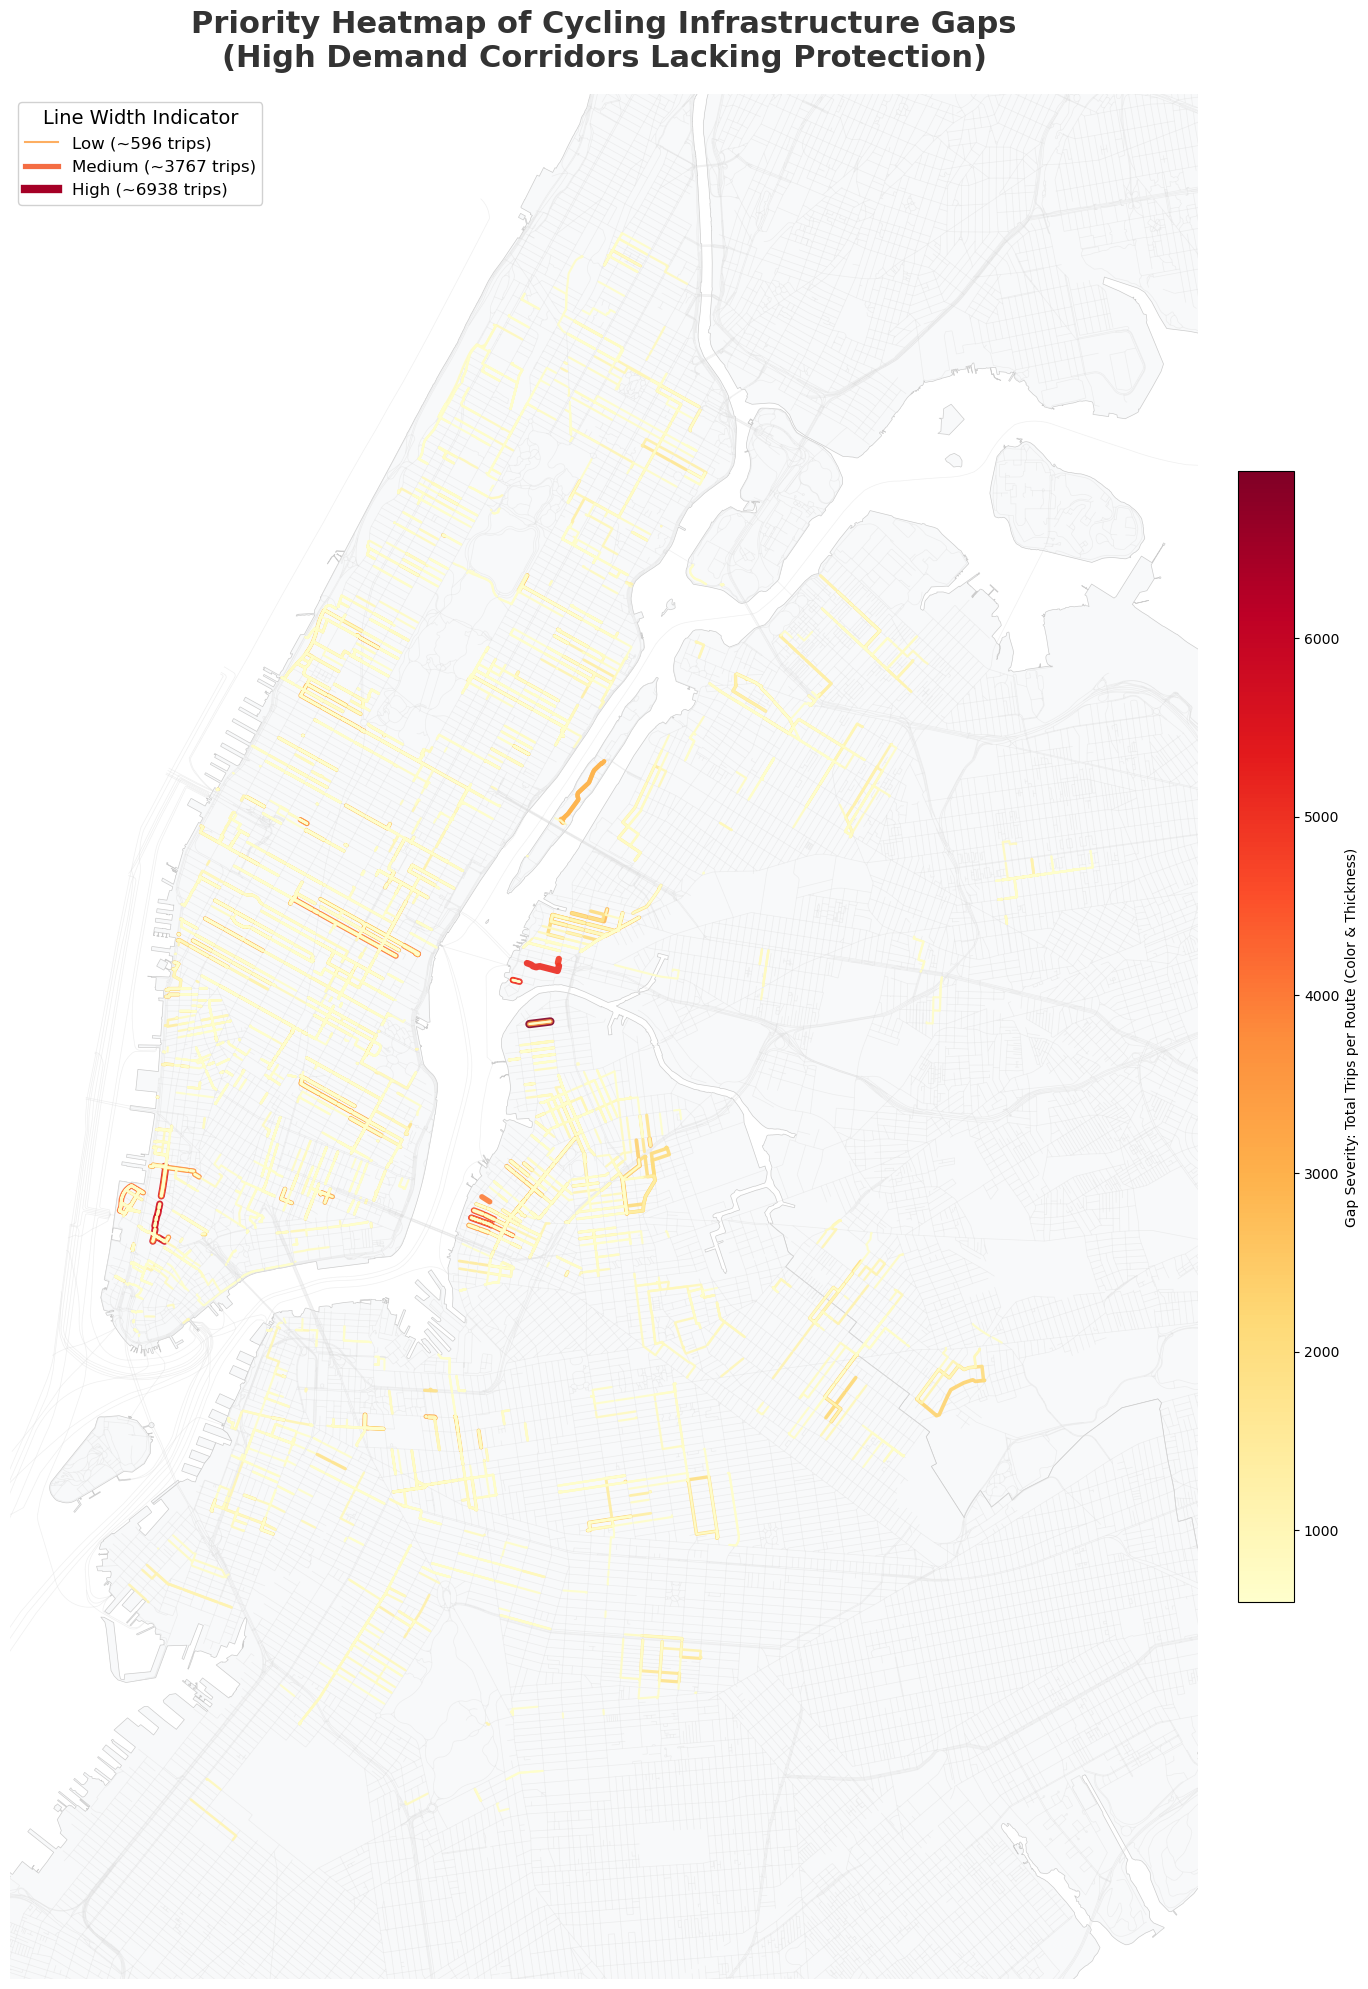

In [3]:
min_trips = gdf_gaps['trip_count'].min()
max_trips = gdf_gaps['trip_count'].max()
mid_trips = (min_trips + max_trips) / 2

gdf_gaps['linewidth'] = np.interp(gdf_gaps['trip_count'], (min_trips, max_trips), (1.5, 6.0))

fig, ax = plt.subplots(figsize=(20, 20))
ax.set_title("Priority Heatmap of Cycling Infrastructure Gaps\n(High Demand Corridors Lacking Protection)", 
             fontsize=22, fontweight='bold', color='#333333', pad=20, loc='center')

ny_boroughs.plot(ax=ax, color='#f8f9fa', edgecolor='#cccccc', linewidth=0.5, zorder=1)
ny_streets.plot(ax=ax, color='#e0e0e0', linewidth=0.5, alpha=0.5, zorder=2)

scatter = gdf_gaps.plot(
    ax=ax,
    column='trip_count',
    cmap='YlOrRd',           
    linewidth=gdf_gaps['linewidth'],
    alpha=0.9,              
    capstyle='round',        
    zorder=3,
    legend=True,
    legend_kwds={
        'label': "Gap Severity: Total Trips per Route (Color & Thickness)",
        'orientation': "vertical",
        'shrink': 0.6,
        'pad': 0.02
    }
)

line_thin = mlines.Line2D([], [], color='#fdae61', linewidth=1.5, label=f'Low (~{int(min_trips)} trips)')
line_med = mlines.Line2D([], [], color='#f46d43', linewidth=3.75, label=f'Medium (~{int(mid_trips)} trips)')
line_thick = mlines.Line2D([], [], color='#a50026', linewidth=6.0, label=f'High (~{int(max_trips)} trips)')

ax.legend(handles=[line_thin, line_med, line_thick], 
          title="Line Width Indicator", 
          loc='upper left', 
          fontsize=12, 
          title_fontsize=14,
          frameon=True,
          facecolor='white',
          edgecolor='#cccccc',
          framealpha=0.9)

minx, miny, maxx, maxy = gdf_gaps.total_bounds
margin = 0.015
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

ax.axis('off')
plt.tight_layout()
plt.subplots_adjust(top=0.95)

OUTPUT_IMAGE = '../../data/processed/priority_heatmap_consistent.png'
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

While the global map provides a macroscopic view of the city's infrastructural deficits, a localized approach is required to understand the underlying urban dynamics. In the following sections, a qualitative "ground-truthing" analysis will be conducted on the five most problematic points identified by the heatmap, utilizing satellite imagery to diagnose the root causes of these gaps and propose potential urban planning solutions.

### Case Study 1: Routing Engine Dynamics in Roosevelt Island

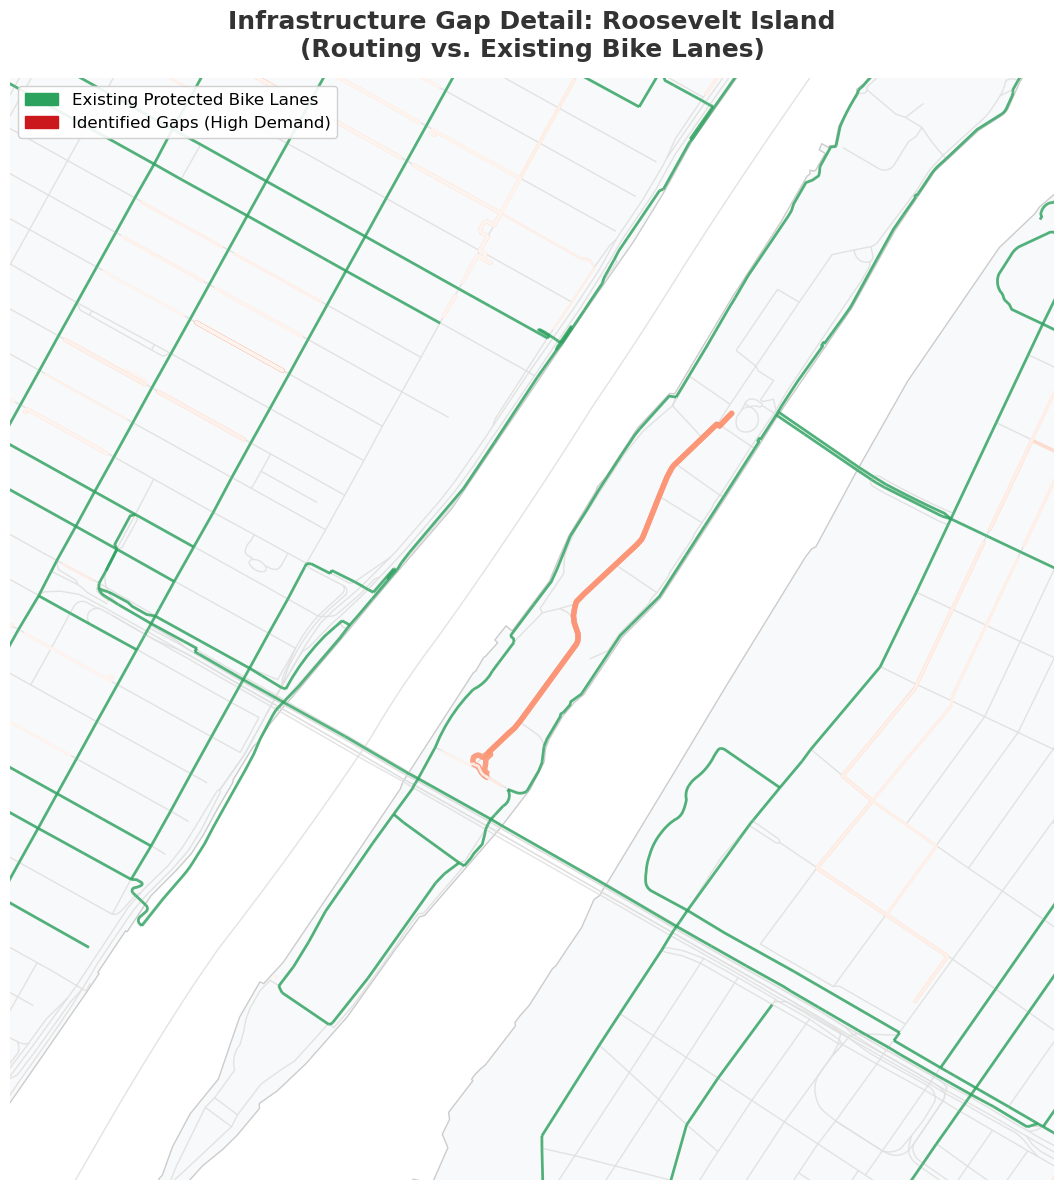

In [13]:
ZOOM_XLIM = (-73.965, -73.940)
ZOOM_YLIM = (40.750, 40.770)

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title("Infrastructure Gap Detail: Roosevelt Island\n(Routing vs. Existing Bike Lanes)", 
             fontsize=18, fontweight='bold', color='#333333', pad=15)

ny_boroughs.plot(ax=ax, color='#f8f9fa', edgecolor='#cccccc', linewidth=1, zorder=1)
ny_streets.plot(ax=ax, color='#e0e0e0', linewidth=1, alpha=0.9, zorder=2)

bike_infra.plot(ax=ax, color='#2ca25f', linewidth=2, alpha=0.8, zorder=3)

scatter = gdf_gaps.plot(
    ax=ax,
    column='trip_count',
    cmap='Reds',
    linewidth=gdf_gaps['linewidth'] * 1.25,
    alpha=0.9,              
    capstyle='round',        
    zorder=4
)

ax.set_xlim(ZOOM_XLIM)
ax.set_ylim(ZOOM_YLIM)

legend_elements = [
    mpatches.Patch(color='#2ca25f', label='Existing Protected Bike Lanes'),
    mpatches.Patch(color='#cb181d', label='Identified Gaps (High Demand)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.9)

ax.axis('off')
plt.tight_layout()

OUTPUT_ZOOM = '../../data/processed/zoom_roosevelt_island.png'
plt.savefig(OUTPUT_ZOOM, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

The first identified anomaly occurs on Roosevelt Island. The heatmap displays a thick red line cutting straight through the center of the island, suggesting a severe lack of infrastructure. However, an inspection of the existing cycling network reveals that a perimeter greenway already surrounds the island. The issue here lies not in the physical infrastructure, but in the mathematical penalizations applied by the GraphHopper routing engine.

The LTS3 (Confident) profile assigns a weight of 65 out of 100 to the total distance of the trip. This indicates that while safety is considered, route directness remains a highly influential factor. Taking the perimeter bike lane instead of the central road increases the total trip distance from approximately 1.0 km to 1.2 km. Although seemingly minor, this 20% increase in distance is penalized heavily enough by the algorithm to make the central, unprotected road the mathematically optimal choice.

Furthermore, a detailed inspection of the main central street via Google Earth shows that it is exceptionally wide, technically allowing for the installation of a central dedicated bike lane. Nevertheless, considering that Roosevelt Island has a relatively low population density and is primarily a recreational area, riders utilizing Citi Bike in this location are likely doing so for leisure rather than high-speed commuting. Therefore, an urgent infrastructural intervention in the center of the island may not be strictly necessary, as the current routing behavior is largely an algorithmic artifact.

### Case Study 2: One-Way Constraints and Connectivity Gaps in Tribeca / WTC

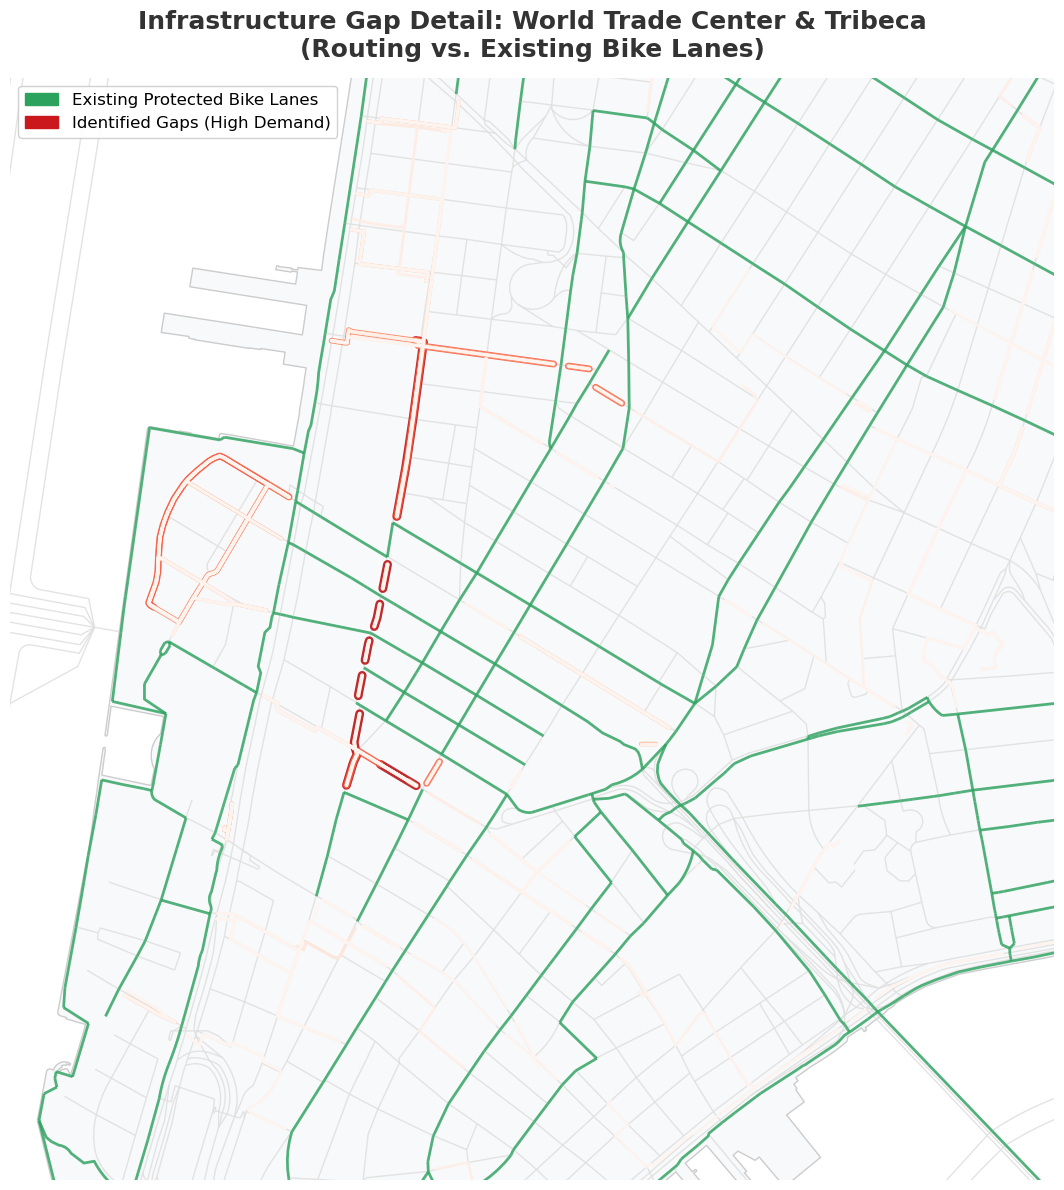

In [15]:
ZOOM_XLIM = (-74.020, -73.995)
ZOOM_YLIM = (40.705, 40.725)

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title("Infrastructure Gap Detail: World Trade Center & Tribeca\n(Routing vs. Existing Bike Lanes)", 
             fontsize=18, fontweight='bold', color='#333333', pad=15)

ny_boroughs.plot(ax=ax, color='#f8f9fa', edgecolor='#cccccc', linewidth=1, zorder=1)
ny_streets.plot(ax=ax, color='#e0e0e0', linewidth=1, alpha=0.9, zorder=2)

bike_infra.plot(ax=ax, color='#2ca25f', linewidth=2, alpha=0.8, zorder=3)

scatter = gdf_gaps.plot(
    ax=ax,
    column='trip_count',
    cmap='Reds',
    linewidth=gdf_gaps['linewidth'] * 1.25,
    alpha=0.9,              
    capstyle='round',        
    zorder=4
)

ax.set_xlim(ZOOM_XLIM)
ax.set_ylim(ZOOM_YLIM)

legend_elements = [
    mpatches.Patch(color='#2ca25f', label='Existing Protected Bike Lanes'),
    mpatches.Patch(color='#cb181d', label='Identified Gaps (High Demand)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.9)

ax.axis('off')
plt.tight_layout()

OUTPUT_ZOOM = '../../data/processed/zoom_wtc_tribeca.png'
plt.savefig(OUTPUT_ZOOM, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

The Lower Manhattan area presents a fundamentally different challenge. While cycling infrastructure is present, a critical hidden variable significantly impacts mobility: a large portion of the protected bike lanes crossing central Manhattan are strictly unidirectional. Consequently, users attempting to maximize their time on safe routes are frequently forced to make extensive detours.

Additionally, the analysis reveals a substantial spatial gap where multiple docking stations exist without any immediately adjacent cycling infrastructure. This forces cyclists to navigate either sidewalks or mixed-traffic roads just to reach their final destination or the nearest protected lane (a classic last-mile connectivity issue).

For this specific case, satellite observation indicates that the avenues in this zone are sufficiently wide, featuring multiple vehicular lanes and expansive pedestrian sidewalks. This spatial availability presents a clear opportunity to implement new cycling infrastructure, even if it implies a shared but traffic calmed lane, to safely bridge the gap between the existing network and the isolated docking stations.

### Case Study 3: Intermodal Commuting at the Queens-Brooklyn Border

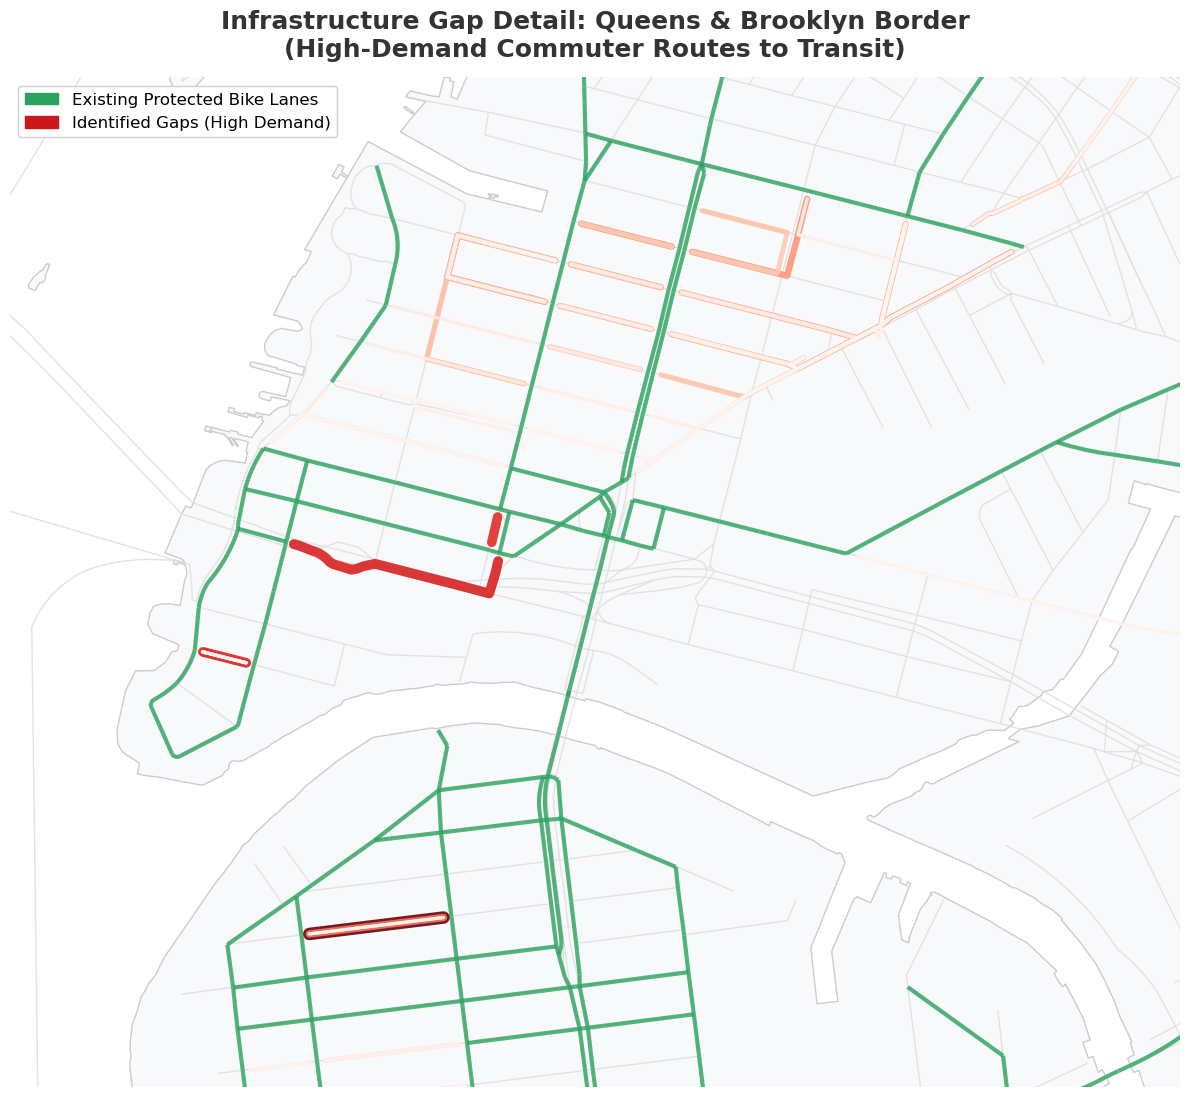

In [16]:
ZOOM_XLIM = (-73.965, -73.939) 
ZOOM_YLIM = (40.733, 40.750)   

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title("Infrastructure Gap Detail: Queens & Brooklyn Border\n(High-Demand Commuter Routes to Transit)", 
             fontsize=18, fontweight='bold', color='#333333', pad=15)

ny_boroughs.plot(ax=ax, color='#f8f9fa', edgecolor='#cccccc', linewidth=1, zorder=1)
ny_streets.plot(ax=ax, color='#e0e0e0', linewidth=1, alpha=0.9, zorder=2)

bike_infra.plot(ax=ax, color='#2ca25f', linewidth=3, alpha=0.8, zorder=3)

scatter = gdf_gaps.plot(
    ax=ax,
    column='trip_count',
    cmap='Reds', 
    linewidth=gdf_gaps['linewidth'] * 1.5,
    alpha=0.9,              
    capstyle='round',        
    zorder=4
)

ax.set_xlim(ZOOM_XLIM)
ax.set_ylim(ZOOM_YLIM)

legend_elements = [
    mpatches.Patch(color='#2ca25f', label='Existing Protected Bike Lanes'),
    mpatches.Patch(color='#cb181d', label='Identified Gaps (High Demand)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.9)

ax.axis('off')
plt.tight_layout()

OUTPUT_ZOOM = '../../data/processed/zoom_queens_brooklyn.png'
plt.savefig(OUTPUT_ZOOM, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

This location highlights an infrastructural deficit driven by intermodality specifically, the use of the bikesharing system as a feeder mode to access heavier public transit. In this area, a major train/subway station serves as a crucial crossing point into central Manhattan. 

The existing cycling infrastructure in the vicinity is not only sparse but, once again, limited by its unidirectional design. This directional restriction, combined with the high volume of commuters rushing to catch a train, inevitably forces cyclists to abandon the fragmented bike network and ride on conventional, unprotected vehicular roads to ensure a direct and timely arrival at the transit hub.

### Case Study 4: The East-West Missing Link in Midtown South

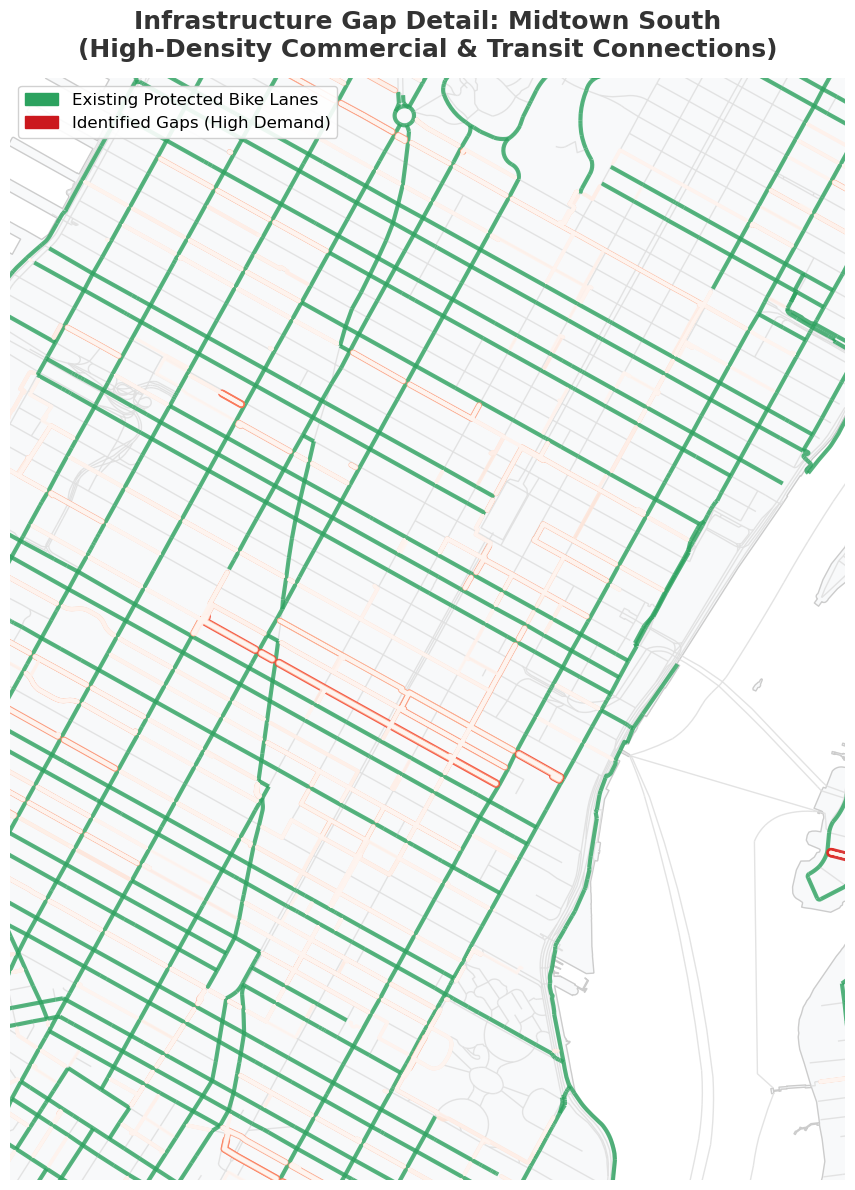

In [7]:
ZOOM_XLIM = (-74.0015, -73.9600)
ZOOM_YLIM = (40.7280, 40.7695)

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title("Infrastructure Gap Detail: Midtown South\n(High-Density Commercial & Transit Connections)", 
             fontsize=18, fontweight='bold', color='#333333', pad=15)

ny_boroughs.plot(ax=ax, color='#f8f9fa', edgecolor='#cccccc', linewidth=1, zorder=1)
ny_streets.plot(ax=ax, color='#e0e0e0', linewidth=1, alpha=0.9, zorder=2)

bike_infra.plot(ax=ax, color='#2ca25f', linewidth=3, alpha=0.8, zorder=3)

scatter = gdf_gaps.plot(
    ax=ax,
    column='trip_count',
    cmap='Reds', 
    linewidth=gdf_gaps['linewidth'] * 1.5,
    alpha=0.9,              
    capstyle='round',        
    zorder=4
)

ax.set_xlim(ZOOM_XLIM)
ax.set_ylim(ZOOM_YLIM)

legend_elements = [
    mpatches.Patch(color='#2ca25f', label='Existing Protected Bike Lanes'),
    mpatches.Patch(color='#cb181d', label='Identified Gaps (High Demand)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.9)

ax.axis('off')
plt.tight_layout()

OUTPUT_ZOOM = '../../data/processed/zoom_midtown_south.png'
plt.savefig(OUTPUT_ZOOM, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

The Midtown South area exhibits two defining characteristics. First, it is a hyper-dense commercial and corporate hub situated around the Empire State Building, generating massive daily foot and vehicular traffic. Second, it serves as a primary entry point for commuters arriving from peripheral boroughs via the subway system.

Given these characteristics, the scarcity of cycling infrastructure is particularly alarming, leaving a massive coverage void in the heart of the district. Similar to previous cases, the existing bike lane situated just below the highlighted red line operates in a single direction. Users needing to travel in the opposite direction while seeking a protected route are subjected to highly inefficient detours.

The intensely red segment identified by the heatmap corresponds to E 31st St, an East-to-West cross-town street.  Satellite imagery reveals that it currently consists of a single vehicular travel lane flanked by parking lanes on both sides. Reallocating this street space, such as repurposing one of the parking lanes to install a dedicated cycling lane, would drastically improve urban micromobility and alleviate the severe East-West connectivity bottleneck in Midtown.

### Case Study 5: Directional Imbalance and Recreational Risks in Williamsburg

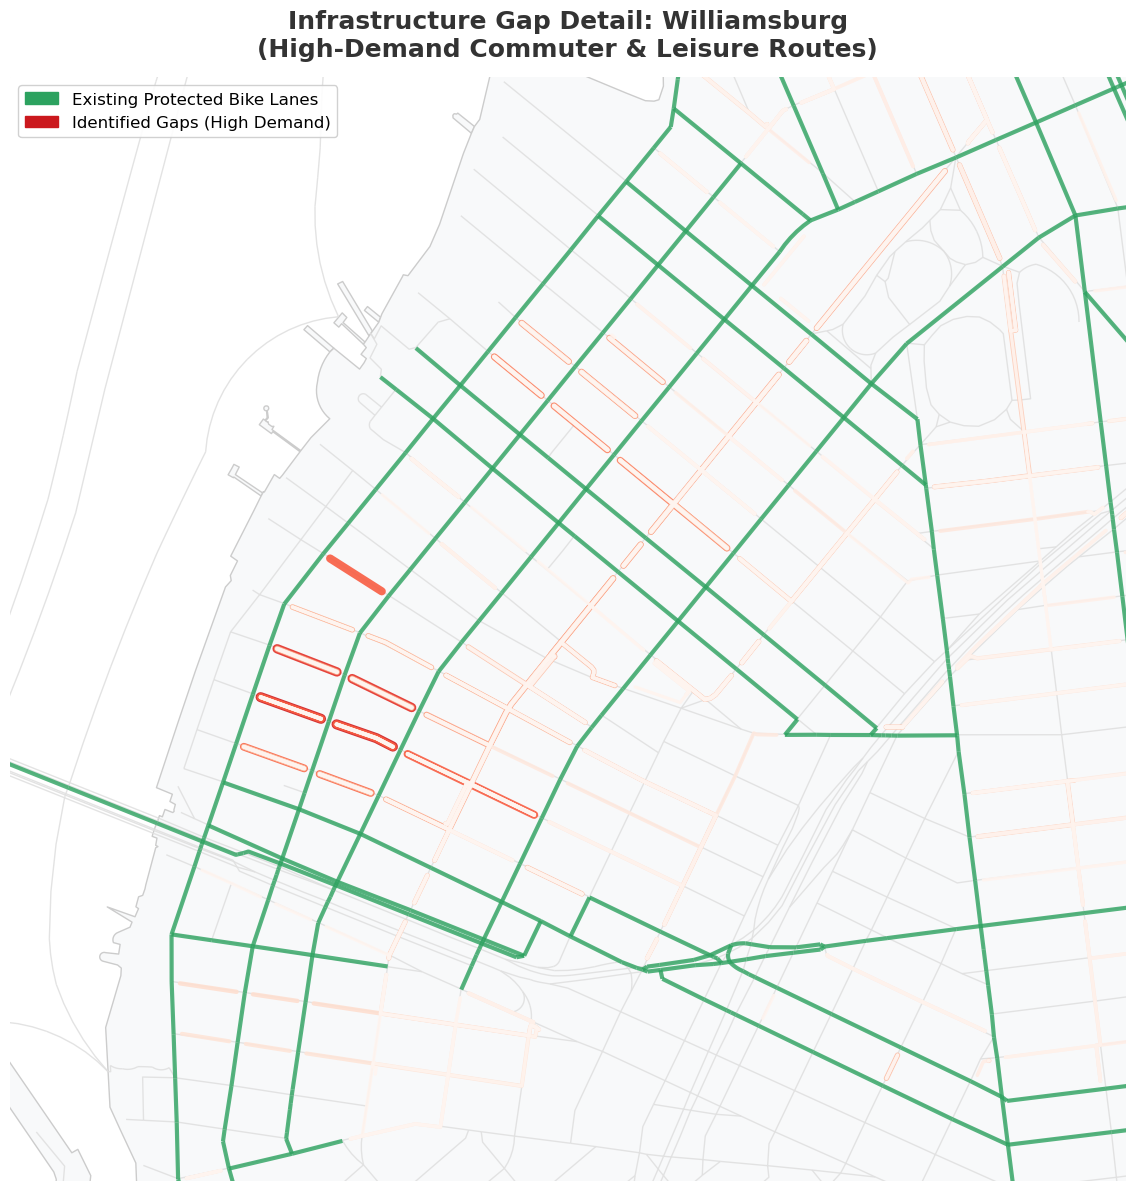

In [10]:
ZOOM_XLIM = (-73.9720, -73.9480) 
ZOOM_YLIM = (40.7068, 40.7248)

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title("Infrastructure Gap Detail: Williamsburg\n(High-Demand Commuter & Leisure Routes)", 
             fontsize=18, fontweight='bold', color='#333333', pad=15)

ny_boroughs.plot(ax=ax, color='#f8f9fa', edgecolor='#cccccc', linewidth=1, zorder=1)
ny_streets.plot(ax=ax, color='#e0e0e0', linewidth=1, alpha=0.9, zorder=2)

bike_infra.plot(ax=ax, color='#2ca25f', linewidth=3, alpha=0.8, zorder=3)

scatter = gdf_gaps.plot(
    ax=ax,
    column='trip_count',
    cmap='Reds', 
    linewidth=gdf_gaps['linewidth'] * 1.5,
    alpha=0.9,              
    capstyle='round',        
    zorder=4
)

ax.set_xlim(ZOOM_XLIM)
ax.set_ylim(ZOOM_YLIM)

legend_elements = [
    mpatches.Patch(color='#2ca25f', label='Existing Protected Bike Lanes'),
    mpatches.Patch(color='#cb181d', label='Identified Gaps (High Demand)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.9)

ax.axis('off')
plt.tight_layout()

OUTPUT_ZOOM = '../../data/processed/zoom_williamsburg.png'
plt.savefig(OUTPUT_ZOOM, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

The final case study focuses on the Williamsburg neighborhood in Brooklyn, specifically the area adjacent to Domino Park. This zone boasts a high density of young residents, a remarkably high cycling mode share, and direct connections to Manhattan via the Williamsburg Bridge and local subway lines.

The infrastructural flaw in this area is a severe directional imbalance: while there is adequate infrastructure for North-South travel, East-West connections are practically non-existent. This is a highly identifiable and solvable problem. Broad avenues in the area, such as Metropolitan Ave (which also features exceptionally wide sidewalks), offer more than enough spatial capacity for the straightforward installation of cross-town bike lanes. 

The lack of these East-West links forces users to choose between massive detours or riding alongside heavy traffic on direct routes. Furthermore, the proximity of these critical gaps to Domino Park implies a high volume of recreational riders. Unlike daily commuters, recreational users are often less experienced (aligning more with an LTS1 or LTS2 profile), which exponentially increases the safety risks when they are forced onto roads not designed to accommodate vulnerable cyclists.